# Google AlphaEarth Satellite Embeddings Dataset Demo

AlphaEarth provides global, analysis-ready 64-dimensional embedding vectors for each 10m land and shallow water pixel. These embeddings summarize complex, multi-source Earth observation data (optical, radar, LiDAR) over a full calendar year, capturing temporal surface condition trajectories.

**Key Features:**
- **64-dimensional embeddings**: Unit-length vectors distributed on a sphere
- **Multi-source fusion**: Combines optical, radar, and LiDAR data
- **Temporal consistency**: Annual composites enabling change detection via vector similarity
- **Analysis-ready**: No preprocessing needed, designed for direct use in ML models
- **Robust**: Handles clouds and missing data through the embedding generation process

## 1. Setup and Authentication

In [1]:
import os
from dotenv import load_dotenv
from matplotlib import pyplot as plt
import numpy as np
import torch
import ee
from torchgeo.datasets import BoundingBox
from forestvision.datasets import GEEAlphaEarth

In [2]:
# Load environment variables from .env file
load_dotenv("../.env")
gee_project = os.getenv("GEE_PROJECT_NAME")

# Authenticate and initialize Earth Engine
ee.Authenticate()
ee.Initialize(project=gee_project)

print(f"Successfully authenticated with project: {gee_project}")

Successfully authenticated with project: forestsegnet


## 2. Define Region of Interest

We'll define a bounding box in the Pacific Northwest (Oregon) where there is significant forest coverage. Note that AlphaEarth has 10m resolution, so the same spatial extent will contain more pixels than TreeMap (30m).

In [3]:
# Define a bounding box for a forested region in Oregon
forest_roi = BoundingBox(
    -2219976.5070072114,  # minx (west)
    -2216076.5070072114,  # maxx (east)
    2650010.507788832,    # miny (south)
    2653910.507788832,    # maxy (north)
    0,                    # mint (start time)
    0,                    # maxt (end time)
)

print(f"ROI Bounds: {forest_roi}")
print(f"Width: {forest_roi.maxx - forest_roi.minx:.1f} meters")
print(f"Height: {forest_roi.maxy - forest_roi.miny:.1f} meters")
print(f"Approximate dimensions at 10m resolution: {int((forest_roi.maxx - forest_roi.minx) / 10)} x {int((forest_roi.maxy - forest_roi.miny) / 10)} pixels")

ROI Bounds: BoundingBox(minx=-2219976.5070072114, maxx=-2216076.5070072114, miny=2650010.507788832, maxy=2653910.507788832, mint=0, maxt=0)
Width: 3900.0 meters
Height: 3900.0 meters
Approximate dimensions at 10m resolution: 390 x 390 pixels


## 3. Load AlphaEarth Dataset

The AlphaEarth dataset provides 64-dimensional embedding vectors (A00-A63). We'll start by loading the default RGB bands (A01, A16, A09) for visualization.

In [4]:
# Create AlphaEarth dataset with default bands for 2023
alphaearth = GEEAlphaEarth(
    year=2023,
    roi=forest_roi,
    res=10,
)

print("AlphaEarth Dataset Information:")
print(alphaearth)
print(f"\nDefault bands (RGB): {alphaearth.bands}")
print(f"All available bands: {alphaearth.all_bands[:5]}... (64 total)")
print(f"Spatial resolution: {alphaearth.res} meters")
print(f"No data value: {alphaearth.nodata}")

AlphaEarth Dataset Information:
GEEAlphaEarth Dataset
    type: GeoDataset
    bbox: BoundingBox(minx=-2219976.5070072114, maxx=-2216076.5070072114, miny=2650010.507788832, maxy=2653910.507788832, mint=0.0, maxt=0.0)
    size: 1

Default bands (RGB): ['A01', 'A16', 'A09']
All available bands: ['A00', 'A01', 'A02', 'A03', 'A04']... (64 total)
Spatial resolution: 10 meters
No data value: 0


### Load Full Embedding Vector

Let's also create a dataset with all 64 embedding dimensions for more comprehensive analysis.

In [5]:
# Create AlphaEarth dataset with all embedding dimensions
alphaearth_full = GEEAlphaEarth(
    year=2023,
    roi=forest_roi,
    res=10,
    bands=tuple([f"A{i:02d}" for i in range(64)])
)

print("Full AlphaEarth Dataset:")
print(f"Selected bands: {len(alphaearth_full.bands)} dimensions")
print(f"Bands: {alphaearth_full.bands[:10]}...")

Full AlphaEarth Dataset:
Selected bands: 64 dimensions
Bands: ('A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09')...


## 4. Fetch and Visualize Data

In [7]:
# Fetch data for the ROI using RGB bands
sample = alphaearth[forest_roi]

# Display sample keys
print("Sample dictionary keys:")
for key in sample.keys():
    print(f"  - {key}")

print(f"\nImage shape: {sample['image'].shape}")
print(f"Data type: {sample['image'].dtype}")
print(f"Value range: [{sample['image'].min():.4f}, {sample['image'].max():.4f}]")

Sample dictionary keys:
  - crs
  - bbox
  - image

Image shape: torch.Size([3, 390, 390])
Data type: torch.float32
Value range: [-0.3647, 0.3460]


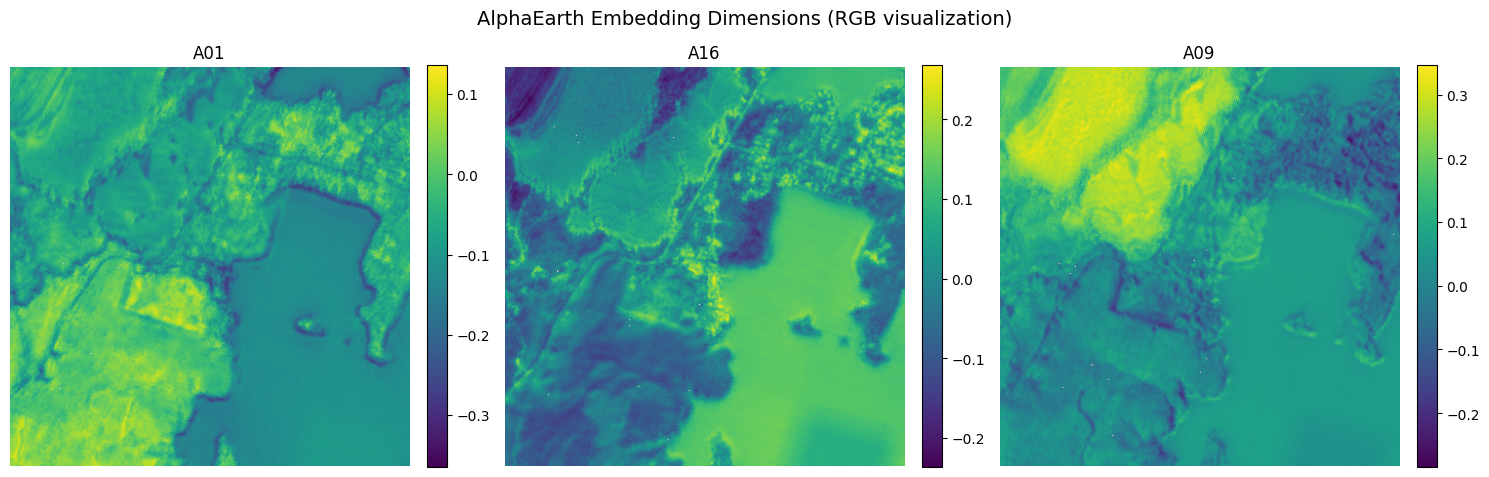

In [9]:
# Visualize individual embedding dimensions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (band_name, ax) in enumerate(zip(alphaearth.bands, axes)):
    band_data = sample["image"][idx].type(torch.float32).numpy()
    band_data[band_data == alphaearth.nodata] = np.nan
    im = ax.imshow(band_data, cmap='viridis')
    ax.set_title(f'{band_name}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('AlphaEarth Embedding Dimensions (RGB visualization)', fontsize=14)
plt.tight_layout()
plt.show()

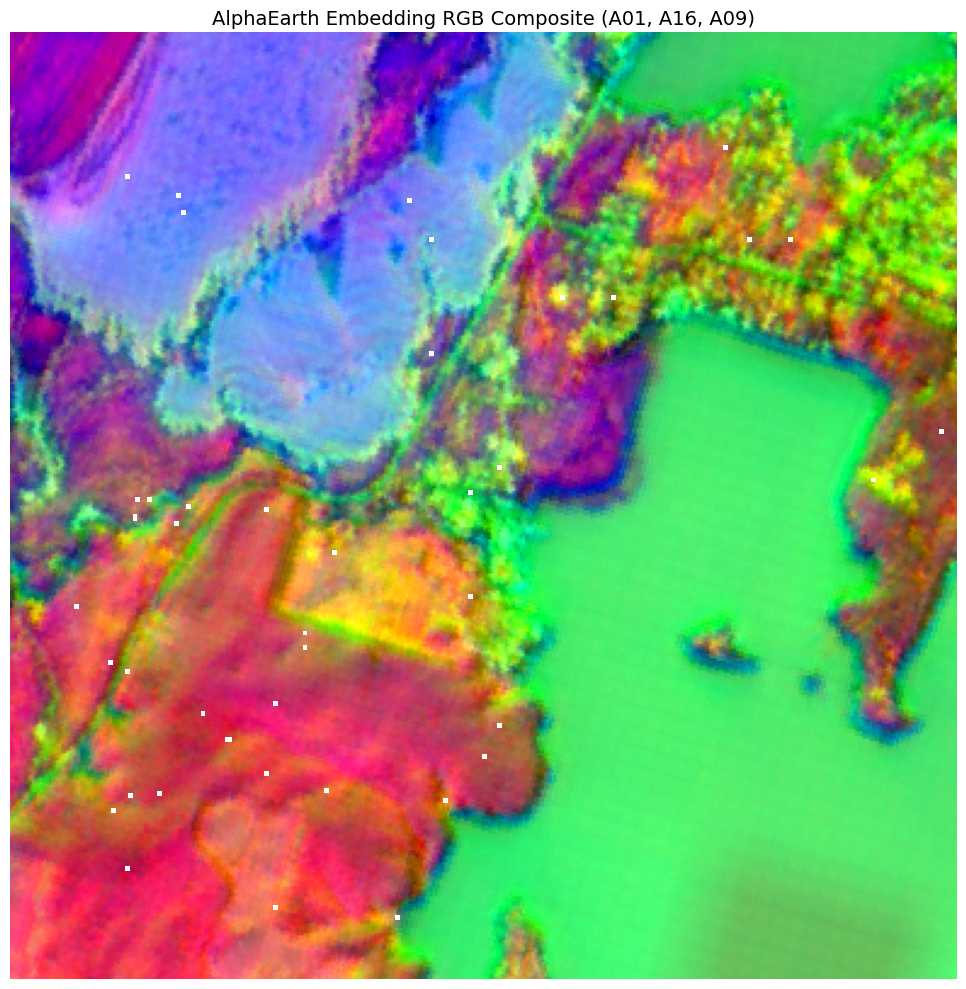

In [11]:
# Visualize as RGB composite
fig, ax = plt.subplots(figsize=(10, 10))

# Stack RGB bands and normalize for visualization
rgb_data = sample["image"][:3].type(torch.float32).numpy()
rgb_data = np.transpose(rgb_data, (1, 2, 0))

# Normalize to [0, 1] for display
for i in range(3):
    band = rgb_data[:, :, i]
    band[band == alphaearth.nodata] = np.nan
    min_val, max_val = np.nanpercentile(band, [2, 98])
    rgb_data[:, :, i] = np.clip((band - min_val) / (max_val - min_val + 1e-8), 0, 1)

ax.imshow(rgb_data)
ax.set_title('AlphaEarth Embedding RGB Composite (A01, A16, A09)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Examine Embedding Characteristics

Let's analyze the distribution of embedding values and their properties.

In [14]:
# Fetch full embedding data
sample_full = alphaearth[forest_roi]

embedding_data = sample_full['image'].type(torch.float32).numpy()
print(f"Full embedding shape: {embedding_data.shape}")
print(f"Embedding data shape: (bands, height, width) = {embedding_data.shape}")

Full embedding shape: (3, 390, 390)
Embedding data shape: (bands, height, width) = (3, 390, 390)


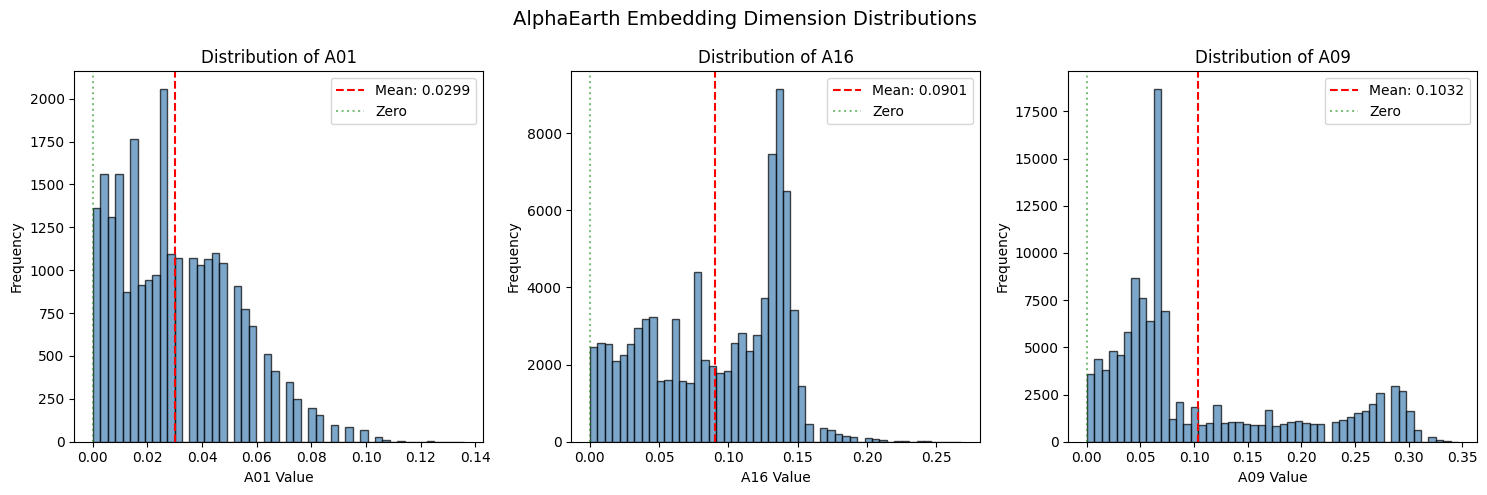

In [20]:
# Visualize distribution of a few embedding dimensions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# selected_dims = ["A00", "A05", "A10", "A20", "A30", "A40"]
selected_dims = ['A01', 'A16', 'A09']

for dim_name, ax in zip(selected_dims, axes.flat):
    dim_idx = alphaearth.bands.index(dim_name)
    data = embedding_data[dim_idx]
    data = data[data > alphaearth.nodata].flatten()
    
    ax.hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel(f'{dim_name} Value')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {dim_name}')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.4f}')
    ax.axvline(0, color='green', linestyle=':', alpha=0.5, label='Zero')
    ax.legend()

plt.suptitle('AlphaEarth Embedding Dimension Distributions', fontsize=14)
plt.tight_layout()
plt.show()

Number of valid pixels: 25333
Embedding dimensions: 3

Vector norm statistics:
  Mean: 0.088057
  Std: 0.037765
  Min: 0.003104
  Max: 0.304368


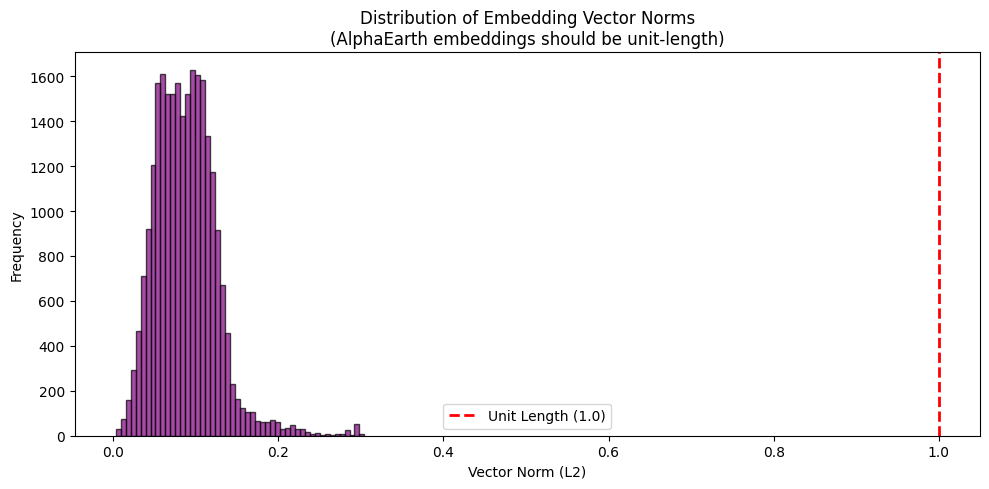

In [21]:
# Examine embedding vector statistics
# Flatten spatial dimensions to get (n_pixels, n_dims)
valid_mask = embedding_data[0] > alphaearth_full.nodata
valid_embeddings = embedding_data[:, valid_mask].T  # Shape: (n_pixels, 64)

print(f"Number of valid pixels: {valid_embeddings.shape[0]}")
print(f"Embedding dimensions: {valid_embeddings.shape[1]}")

# Calculate vector norms (should be close to 1 since embeddings are unit-length)
vector_norms = np.linalg.norm(valid_embeddings, axis=1)
print(f"\nVector norm statistics:")
print(f"  Mean: {vector_norms.mean():.6f}")
print(f"  Std: {vector_norms.std():.6f}")
print(f"  Min: {vector_norms.min():.6f}")
print(f"  Max: {vector_norms.max():.6f}")

# Visualize vector norm distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(vector_norms, bins=50, color='purple', edgecolor='black', alpha=0.7)
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Unit Length (1.0)')
ax.set_xlabel('Vector Norm (L2)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Embedding Vector Norms\n(AlphaEarth embeddings should be unit-length)')
ax.legend()
plt.tight_layout()
plt.show()